In [6]:
import os, re, math, json, random, shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

random.seed(0); np.random.seed(0)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

DATASET_ROOT = Path("Dataset")          
WORK_ROOT    = Path("yolo_pose_plate")  
IMG_W, IMG_H = 720, 1160                 # CCPD image resolution

TEST_FRAC = 0.15        # fraction held out for the final, frozen test set
N_FOLDS   = 4           # number of folds

MAX_IMAGES        = 8000   # we downsample the dataset in order to keep training times manageable
MIN_PER_SUBSET    = 50    # minimum number of images of a certain subset of ccpd to include in the used dataset


def discover_subset(p: Path) -> str:
    '''Subset = first folder under DATASET_ROOT, e.g. <root>/ccpd_rotate/x.jpg -> ccpd_rotate.'''
    try:
        rel = p.relative_to(DATASET_ROOT); parts = rel.parts
        return parts[0] if len(parts) > 1 else "unknown"
    except ValueError:
        return "unknown"

print("CCPD root :", DATASET_ROOT.resolve(), "| exists:", DATASET_ROOT.exists())
print("Work root :", WORK_ROOT.resolve())
print(f"Plan: hold out {TEST_FRAC:.0%} as test, then {N_FOLDS}-fold CV on the rest")

CCPD root : C:\Users\PC\Desktop\Github\IS_Project\Dataset | exists: True
Work root : C:\Users\PC\Desktop\Github\IS_Project\yolo_pose_plate
Plan: hold out 15% as test, then 4-fold CV on the rest


In [7]:
PROVINCES = ['皖','沪','津','渝','冀','晋','蒙','辽','吉','黑','苏','浙','京',
             '闽','赣','鲁','豫','鄂','湘','粤','桂','琼','川','贵','云','藏',
             '陕','甘','青','宁','新','警','学','O']            # 34
ALPHABETS = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
             'P','Q','R','S','T','U','V','W','X','Y','Z','O']   # 25
ADS = ['A','B','C','D','E','F','G','H','J','K','L','M','N',
       'P','Q','R','S','T','U','V','W','X','Y','Z',
       '0','1','2','3','4','5','6','7','8','9','O']             # 35

def parse_ccpd_filename(path):
    name = Path(path).stem
    f = name.split('-')
    if len(f) != 7: return None
    f_area, f_tilt, f_bbox, f_verts, f_label, f_bright, f_blur = f
    try:
        (x1,y1),(x2,y2) = [tuple(map(int,p.split('&'))) for p in f_bbox.split('_')]
        verts = [tuple(map(int,p.split('&'))) for p in f_verts.split('_')]
        if len(verts) != 4: return None
        idxs = list(map(int, f_label.split('_')))
        if len(idxs) != 7: return None
        plate = PROVINCES[idxs[0]] + ALPHABETS[idxs[1]] + ''.join(ADS[i] for i in idxs[2:])
    except (ValueError, IndexError):
        return None
    return {"path": str(path), "bbox": (x1,y1,x2,y2), "vertices": verts, "plate": plate}

# sanity
_t = "025-95_113-154&383_386&473-386&473_177&454_154&383_363&402-0_0_22_27_27_33_16-95-9.jpg"
print(parse_ccpd_filename(_t))

{'path': '025-95_113-154&383_386&473-386&473_177&454_154&383_363&402-0_0_22_27_27_33_16-95-9.jpg', 'bbox': (154, 383, 386, 473), 'vertices': [(386, 473), (177, 454), (154, 383), (363, 402)], 'plate': '皖AY339S'}


In [8]:
def order_corners(pts):
    '''Return the 4 points ordered as TL, TR, BR, BL.
    Robust to input order. pts: list/array of 4 (x, y).'''
    pts = np.asarray(pts, dtype=np.float32)
    s = pts.sum(axis=1)        # x + y
    d = np.diff(pts, axis=1).ravel()  # y - x
    tl = pts[np.argmin(s)]     # smallest x+y: top left
    br = pts[np.argmax(s)]     # largest  x+y: bottom right
    tr = pts[np.argmin(d)]     # smallest y-x: top right
    bl = pts[np.argmax(d)]     # largest  y-x: bottom left
    return np.stack([tl, tr, br, bl])

# quick test on the sample vertices
_v = parse_ccpd_filename(_t)["vertices"]
print("raw   :", _v)
print("sorted:", order_corners(_v).tolist())

raw   : [(386, 473), (177, 454), (154, 383), (363, 402)]
sorted: [[154.0, 383.0], [363.0, 402.0], [386.0, 473.0], [177.0, 454.0]]


In [9]:
def to_pose_line(rec):
    '''Build one Ultralytics pose label line from a parsed record. None if invalid.
    Format: class cx cy w h  x1 y1 v1  x2 y2 v2  x3 y3 v3  x4 y4 v4  (all normalized).'''
    x1,y1,x2,y2 = rec["bbox"]
    if x2 <= x1 or y2 <= y1: return None
    cx = (x1+x2)/2 / IMG_W; cy = (y1+y2)/2 / IMG_H
    w  = (x2-x1)   / IMG_W;  h = (y2-y1)   / IMG_H
    corners = order_corners(rec["vertices"])
    kpts = []
    for (kx, ky) in corners:
        kpts += [kx/IMG_W, ky/IMG_H, 2]   # visibility flag 2 = visible
    vals = [0, cx, cy, w, h] + kpts
    # soft-clip any coordinate that grazes outside [0,1] (a few CCPD boxes touch the border)
    coords_to_check = [cx,cy,w,h] + [k for j,k in enumerate(kpts) if j%3!=2]
    if any((v < 0 or v > 1) for v in coords_to_check):
        vals = [vals[0]] + [min(max(v,0.0),1.0) for v in vals[1:]]
        # restore visibility flags (they were clipped to 1.0 above; set back to 2)
        for i in range(4):
            vals[5 + i*3 + 2] = 2
    return " ".join(f"{v:.6f}" if isinstance(v,float) else str(v) for v in vals)

# sanity
_rec = parse_ccpd_filename(_t)
print(to_pose_line(_rec))

0 0.375000 0.368966 0.322222 0.077586 0.21388888 0.33017242 2 0.50416666 0.34655172 2 0.5361111 0.40775862 2 0.24583334 0.3913793 2


In [10]:
def gather_by_subset(root):
    by = {}
    for p in root.rglob("*.jpg"):
        by.setdefault(discover_subset(p), []).append(p)
    return by

def stratified_sample(by_subset, max_images, min_per_subset, seed=0):
    '''Sample up to max_images, proportional to subset sizes, with a floor per subset.
    Returns {subset: [paths]}.'''
    rng = random.Random(seed)
    subsets = {k: list(v) for k, v in by_subset.items()}
    for v in subsets.values():
        rng.shuffle(v)
    total = sum(len(v) for v in subsets.values())
    if max_images is None or max_images >= total:
        return subsets  # use everything

    # 1) give each subset its floor (capped at what it has)
    alloc = {k: min(min_per_subset, len(v)) for k, v in subsets.items()}
    used = sum(alloc.values())
    remaining = max_images - used

    # 2) distribute the remainder proportionally to leftover capacity
    if remaining > 0:
        leftover = {k: len(v) - alloc[k] for k, v in subsets.items()}
        leftover_total = sum(leftover.values())
        if leftover_total > 0:
            for k in subsets:
                add = int(round(remaining * leftover[k] / leftover_total))
                alloc[k] = min(len(subsets[k]), alloc[k] + add)
    # since we can overshoot the maximum number of images by results of rounding errors, we remove images over the the cap 
    over = sum(alloc.values()) - max_images
    if over > 0:
        for k in sorted(alloc, key=lambda z: alloc[z], reverse=True):
            cut = min(over, alloc[k] - min(min_per_subset, len(subsets[k])))
            alloc[k] -= max(cut, 0); over -= max(cut, 0)
            if over <= 0: break

    return {k: subsets[k][:alloc[k]] for k in subsets}

def stratified_test_split(sampled, test_frac, seed=0):
    '''Return (pool, test) dicts {subset:[paths]}, splitting within each subset.'''
    rng = random.Random(seed + 1)
    pool, test = {}, {}
    for k, v in sampled.items():
        v = list(v); rng.shuffle(v)
        n_test = int(round(len(v) * test_frac))
        test[k] = v[:n_test]
        pool[k] = v[n_test:]
    return pool, test

def write_split(paths_by_subset, work, split_name, verbose=True):
    img_dir = work/"images"/split_name; lbl_dir = work/"labels"/split_name
    img_dir.mkdir(parents=True, exist_ok=True); lbl_dir.mkdir(parents=True, exist_ok=True)
    ok = skip = 0
    subset_counts = {}
    for subset, plist in paths_by_subset.items():
        c = 0
        for p in plist:
            rec = parse_ccpd_filename(p)
            if rec is None: skip += 1; continue
            line = to_pose_line(rec)
            if line is None: skip += 1; continue
            stem = Path(p).stem
            img_dst = img_dir/(stem + ".jpg"); lbl_dst = lbl_dir/(stem + ".txt")
            if not img_dst.exists():
               shutil.copy(p, img_dst)
            lbl_dst.write_text(line + "\n")
            ok += 1; c += 1
        subset_counts[subset] = c
    if verbose:
        print(f"  {split_name:5s}: {ok:,} written, {skip} skipped | by subset: {subset_counts}")
    return subset_counts

by_subset = gather_by_subset(DATASET_ROOT)
print("Subsets found:", {k: len(v) for k, v in by_subset.items()})

sampled = stratified_sample(by_subset, MAX_IMAGES, MIN_PER_SUBSET, seed=0)
print("After stratified sampling:", {k: len(v) for k, v in sampled.items()},
      "| total =", sum(len(v) for v in sampled.values()))

pool, test = stratified_test_split(sampled, TEST_FRAC, seed=0)
print("Pool total:", sum(len(v) for v in pool.values()),
      "| Test total:", sum(len(v) for v in test.values()))

# fresh build
if WORK_ROOT.exists():
    shutil.rmtree(WORK_ROOT)
pool_counts = write_split(pool, WORK_ROOT, "pool")
test_counts = write_split(test, WORK_ROOT, "test")

# Save the subset label for every pooled image — needed for stratified K-fold next.
pool_subset_of = {}
for subset, plist in pool.items():
    for p in plist:
        pool_subset_of[Path(p).stem] = subset
import pickle as _pickle
(WORK_ROOT/"pool_subset_of.pkl").write_bytes(_pickle.dumps(pool_subset_of))
print("Saved pool subset map for", len(pool_subset_of), "images")

Subsets found: {'ccpd_base': 199996, 'ccpd_blur': 20611, 'ccpd_challenge': 50003, 'ccpd_db': 10132, 'ccpd_fn': 20967, 'ccpd_np': 3036, 'ccpd_rotate': 10053, 'ccpd_tilt': 30216, 'ccpd_weather': 9999, 'CCPD2019': 355013, 'runs': 516}
After stratified sampling: {'ccpd_base': 2148, 'ccpd_blur': 266, 'ccpd_challenge': 574, 'ccpd_db': 156, 'ccpd_fn': 269, 'ccpd_np': 81, 'ccpd_rotate': 155, 'ccpd_tilt': 367, 'ccpd_weather': 154, 'CCPD2019': 3775, 'runs': 55} | total = 8000
Pool total: 6802 | Test total: 1198
  pool : 6,659 written, 143 skipped | by subset: {'ccpd_base': 1826, 'ccpd_blur': 226, 'ccpd_challenge': 488, 'ccpd_db': 133, 'ccpd_fn': 229, 'ccpd_np': 0, 'ccpd_rotate': 132, 'ccpd_tilt': 312, 'ccpd_weather': 131, 'CCPD2019': 3182, 'runs': 0}
  test : 1,175 written, 23 skipped | by subset: {'ccpd_base': 322, 'ccpd_blur': 40, 'ccpd_challenge': 86, 'ccpd_db': 23, 'ccpd_fn': 40, 'ccpd_np': 0, 'ccpd_rotate': 23, 'ccpd_tilt': 55, 'ccpd_weather': 23, 'CCPD2019': 563, 'runs': 0}
Saved pool subs

In [11]:
import pickle as _pickle
pool_subset_of = _pickle.loads((WORK_ROOT/"pool_subset_of.pkl").read_bytes())

def make_stratified_folds(pool_subset_of, n_folds, seed=0):
    '''Assign each pooled image a fold id 0..n_folds-1, stratified within each subset.
    Returns {stem: fold_id}.'''
    rng = random.Random(seed + 7)
    by_subset = {}
    for stem, subset in pool_subset_of.items():
        by_subset.setdefault(subset, []).append(stem)
    fold_of = {}
    for subset, stems in by_subset.items():
        stems = list(stems); rng.shuffle(stems)
        for i, stem in enumerate(stems):
            fold_of[stem] = i % n_folds   # round-robin to give each fold a proportional number of images from each subset
    return fold_of

fold_of = make_stratified_folds(pool_subset_of, N_FOLDS, seed=0)

# report fold sizes and per-subset balance
from collections import Counter
fold_sizes = Counter(fold_of.values())
print("Fold sizes:", dict(sorted(fold_sizes.items())))
# sanity: per-subset spread across folds
import pandas as pd
bal = pd.DataFrame(
    [(pool_subset_of[s], f) for s, f in fold_of.items()],
    columns=["subset", "fold"]
).pivot_table(index="subset", columns="fold", aggfunc=len, fill_value=0)
print("\nImages per (subset × fold):"); print(bal)

Fold sizes: {0: 1686, 1: 1682, 2: 1680, 3: 1678}

Images per (subset × fold):
fold              0    1    2    3
subset                            
CCPD2019        802  802  802  802
ccpd_base       453  453  452  452
ccpd_blur        56   55   55   55
ccpd_challenge  120  120  120  119
ccpd_db          33   33   33   32
ccpd_fn          57   56   56   56
ccpd_np          18   17   17   17
ccpd_rotate      33   32   32   32
ccpd_tilt        77   77   77   77
ccpd_weather     33   33   32   32
runs              4    4    4    4


In [12]:
POOL_IMG = (WORK_ROOT/"images"/"pool").resolve()

def write_fold_yaml(fold_id, fold_of, work):
    '''Write train.txt / val.txt (lists of image paths) and a YAML for one fold.'''
    fdir = work/"folds"/f"fold{fold_id}"
    fdir.mkdir(parents=True, exist_ok=True)
    train_list, val_list = [], []
    for stem, f in fold_of.items():
        line = str(POOL_IMG/(stem + ".jpg"))
        (val_list if f == fold_id else train_list).append(line)
    (fdir/"train.txt").write_text("\n".join(train_list) + "\n")
    (fdir/"val.txt").write_text("\n".join(val_list) + "\n")

    yaml_text = f'''# Fold {fold_id} of {N_FOLDS} — CCPD plate corner pose
path: {work.resolve()}
train: {(fdir/'train.txt').resolve()}
val: {(fdir/'val.txt').resolve()}

kpt_shape: [4, 3]
flip_idx: [1, 0, 3, 2]
names:
  0: plate
'''
    yp = fdir/"plate_pose.yaml"
    yp.write_text(yaml_text)
    return yp, len(train_list), len(val_list)

fold_yamls = []
for k in range(N_FOLDS):
    yp, ntr, nva = write_fold_yaml(k, fold_of, WORK_ROOT)
    fold_yamls.append(yp)
    print(f"fold {k}: train={ntr:,}  val={nva:,}  → {yp}")

final_yaml_text = f'''# Final: train on full pool, test on frozen test set
path: {WORK_ROOT.resolve()}
train: images/pool
val: images/test     
test: images/test

kpt_shape: [4, 3]
flip_idx: [1, 0, 3, 2]
names:
  0: plate
'''
final_yaml = WORK_ROOT/"plate_pose_final.yaml"
final_yaml.write_text(final_yaml_text)
print("\nfinal YAML:", final_yaml)

fold 0: train=5,040  val=1,686  → yolo_pose_plate\folds\fold0\plate_pose.yaml
fold 1: train=5,044  val=1,682  → yolo_pose_plate\folds\fold1\plate_pose.yaml
fold 2: train=5,046  val=1,680  → yolo_pose_plate\folds\fold2\plate_pose.yaml
fold 3: train=5,048  val=1,678  → yolo_pose_plate\folds\fold3\plate_pose.yaml

final YAML: yolo_pose_plate\plate_pose_final.yaml


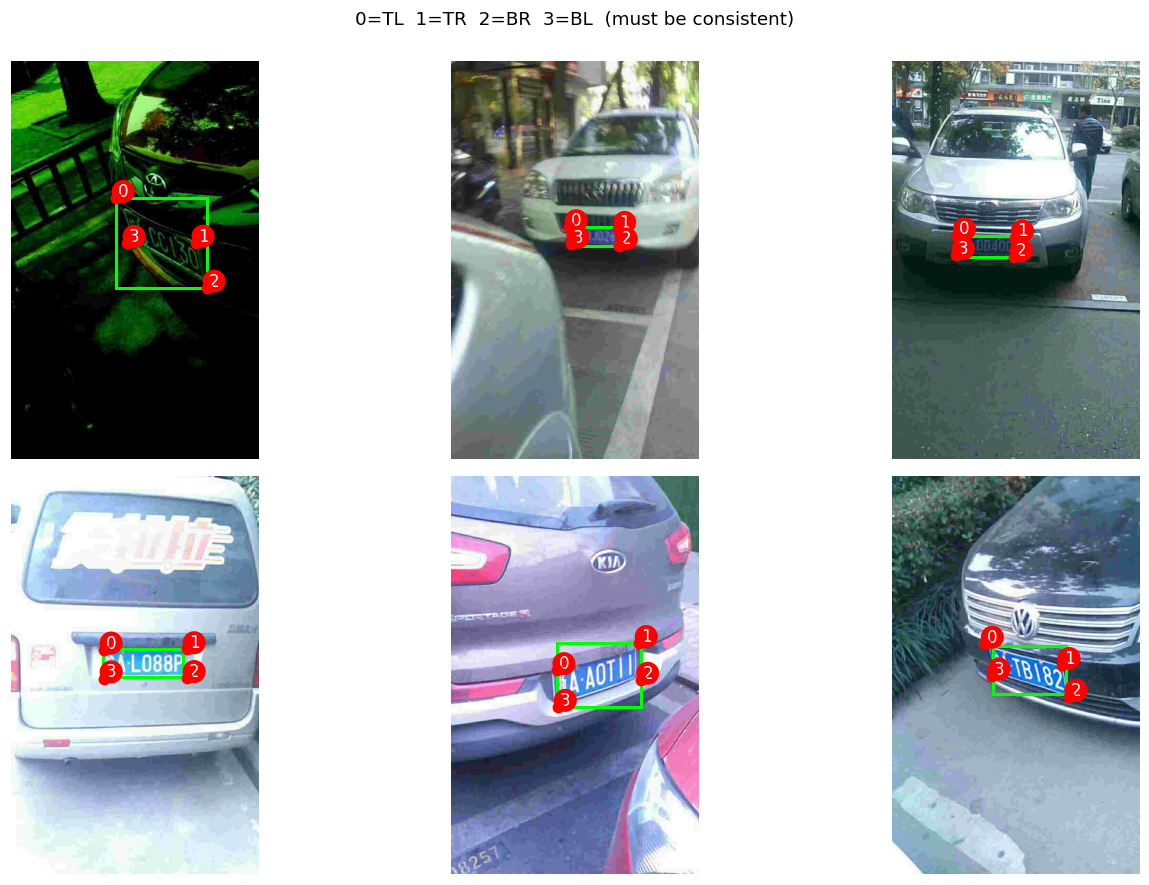

In [13]:
def preview_labels(work, sp="train", n=6, seed=0):
    lbls = sorted((work/"labels"/sp).glob("*.txt"))
    if not lbls: print("no labels found"); return
    rng = random.Random(seed); rng.shuffle(lbls)
    lbls = lbls[:n]
    cols=3; rows=math.ceil(len(lbls)/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4.5, rows*4))
    axes = np.array(axes).reshape(-1)
    for ax, lp in zip(axes, lbls):
        img_p = work/"images"/sp/(lp.stem + ".jpg")
        img = Image.open(img_p).convert("RGB"); W,H = img.size
        ax.imshow(img)
        vals = list(map(float, lp.read_text().split()))
        cx,cy,w,h = vals[1:5]
        x1=(cx-w/2)*W; y1=(cy-h/2)*H
        ax.add_patch(plt.Rectangle((x1,y1), w*W, h*H, fill=False, edgecolor="lime", lw=2))
        kp = vals[5:]
        for i in range(4):
            kx, ky = kp[i*3]*W, kp[i*3+1]*H
            ax.scatter([kx],[ky], c="red", s=45, zorder=5)
            ax.text(kx+5, ky-5, str(i), color="white", fontsize=11,
                    bbox=dict(boxstyle="circle,pad=0.15", fc="red", ec="none"))
        ax.axis("off")
    for ax in axes[len(lbls):]: ax.axis("off")
    plt.suptitle("0=TL  1=TR  2=BR  3=BL  (must be consistent)", y=1.0)
    plt.tight_layout(); plt.show()

preview_labels(WORK_ROOT, "pool", n=6)

In [14]:
try:
    import ultralytics
    from ultralytics import YOLO
    ultralytics.checks()
except ImportError:
    print("Ultralytics not installed. Run:  pip install ultralytics  (then restart the kernel)")

Ultralytics 8.4.60  Python-3.12.0 torch-2.5.1+cu121 CPU (Intel Core i3-14100)
Setup complete  (8 CPUs, 15.8 GB RAM, 415.1/446.3 GB disk)


In [15]:
# Shared training hyperparameters
IMGSZ   = 640      
BATCH   = 8       
DEVICE  = 0        
PATIENCE = 15

def run_cross_validation(size="s", pretrained=True, epochs=50, n_folds=N_FOLDS,
                         imgsz=IMGSZ, batch=BATCH, device=DEVICE, tag_prefix=""):
    '''Train `size`/`pretrained` config across all folds. Returns (per_fold_df, summary_dict).'''
    weights = f"yolo11{size}-pose.pt" if pretrained else f"yolo11{size}-pose.yaml"
    cfg_tag = f"{tag_prefix}yolo11{size}_{'pretrained' if pretrained else 'scratch'}"
    rows = []
    for k in range(0, n_folds):
        run_name = f"{cfg_tag}_fold{k}"
        m = YOLO(weights)
        m.train(data=str(fold_yamls[k]), epochs=epochs, imgsz=imgsz, batch=batch,
                device=device, patience=PATIENCE, fliplr=0.0, flipud=0.0,
                project="runs_plate_pose", name=run_name, exist_ok=True, verbose=False)
        # validate on this fold's val slice (the held-out fold)
        mv = m.val(data=str(fold_yamls[k]), split="val",
                   project="runs_plate_pose", name=run_name+"_val", exist_ok=True)
        try:
            row = {"fold": k,
                   "pose_mAP50-95": float(mv.pose.map),
                   "pose_mAP50":    float(mv.pose.map50),
                   "box_mAP50-95":  float(mv.box.map)}
        except Exception:
            row = {"fold": k, "pose_mAP50-95": np.nan, "pose_mAP50": np.nan, "box_mAP50-95": np.nan}
        rows.append(row)
        print(f"  fold {k}: pose_mAP50-95={row['pose_mAP50-95']:.4f}")
    df = pd.DataFrame(rows)
    summary = {
        "config": cfg_tag,
        "pose_mAP50-95_mean": df["pose_mAP50-95"].mean(),
        "pose_mAP50-95_std":  df["pose_mAP50-95"].std(),
        "pose_mAP50_mean":    df["pose_mAP50"].mean(),
        "box_mAP50-95_mean":  df["box_mAP50-95"].mean(),
    }
    return df, summary

In [16]:
EPOCHS_CV = 40   # per fold; tune to your time budget

cv_df, cv_summary = run_cross_validation(size="m", pretrained=True, epochs=EPOCHS_CV)
print("\nPer-fold results:")
display(cv_df)  
print("\nCross-validated summary:")
print(f"  pose mAP50-95 = {cv_summary['pose_mAP50-95_mean']:.4f} ± {cv_summary['pose_mAP50-95_std']:.4f}")
print(f"  pose mAP50    = {cv_summary['pose_mAP50_mean']:.4f}")
print(f"  box  mAP50-95 = {cv_summary['box_mAP50-95_mean']:.4f}")

New https://pypi.org/project/ultralytics/8.4.65 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.60  Python-3.12.0 torch-2.5.1+cu121 


ValueError: Invalid CUDA 'device=0' requested. Use 'device=cpu' or pass valid CUDA device(s) if available, i.e. 'device=0' or 'device=0,1,2,3' for Multi-GPU.

torch.cuda.is_available(): False
torch.cuda.device_count(): 0
os.environ['CUDA_VISIBLE_DEVICES']: None
See https://pytorch.org/get-started/locally/ for up-to-date torch install instructions if no CUDA devices are seen by torch.


In [ ]:
RUN_GRID_CV = True   # set True to run the full cross-validated comparison (slow!)

EPOCHS_GRID = 40
grid = [
    #("n", True),
    #("n", False),
     ("s", True),
    ("s", False),
    # ("m", True),
    # ("m", False),
]

if RUN_GRID_CV:
    summaries = []
    per_fold_all = []
    for size, pre in grid:
        print(f"\n=== CV for yolo11{size} pretrained={pre} ===")
        dfk, summ = run_cross_validation(size=size, pretrained=pre, epochs=EPOCHS_GRID)
        dfk["config"] = summ["config"]; per_fold_all.append(dfk)
        summaries.append(summ)
    comp = pd.DataFrame(summaries)
    comp["pose_mAP50-95"] = comp.apply(
        lambda r: f"{r['pose_mAP50-95_mean']:.4f} ± {r['pose_mAP50-95_std']:.4f}", axis=1)
    display(comp[["config","pose_mAP50-95","pose_mAP50_mean","box_mAP50-95_mean"]])
    comp.to_csv("plate_pose_small_cv_comparison.csv", index=False)
    pd.concat(per_fold_all, ignore_index=True).to_csv("plate_pose_cv_perfold.csv", index=False)
    print("\nsaved plate_pose_cv_comparison.csv and plate_pose_cv_perfold.csv")
else:
    print("Set RUN_GRID_CV = True to run the cross-validated size × pretrained comparison.")


=== CV for yolo11s pretrained=True ===
New https://pypi.org/project/ultralytics/8.4.62 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.14.5 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060, 5739MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_pose_plate/folds/fold0/plate_pose.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=

,config,pose_mAP50-95,pose_mAP50_mean,box_mAP50-95_mean
0,yolo11s_pretrained,0.9922 ± 0.0008,0.994153,0.791250
1,yolo11s_scratch,0.9923 ± 0.0008,0.994554,0.782502



saved plate_pose_cv_comparison.csv and plate_pose_cv_perfold.csv


In [ ]:
FINAL_SIZE       = "m"
FINAL_PRETRAINED = True
FINAL_EPOCHS     = 50

final_weights = f"yolo11{FINAL_SIZE}-pose.pt" if FINAL_PRETRAINED else f"yolo11{FINAL_SIZE}-pose.yaml"
final_model = YOLO(final_weights)
final_model.train(
    data=str(final_yaml), epochs=FINAL_EPOCHS, imgsz=IMGSZ, batch=BATCH,
    device=DEVICE, patience=PATIENCE, fliplr=0.0, flipud=0.0,
    project="runs_plate_pose", name="final_model", exist_ok=True, verbose=True,
)

test_metrics = final_model.val(data=str(final_yaml), split="test",
                               project="runs_plate_pose", name="final_model_test", exist_ok=True)
try:
    print("\n=== FINAL TEST-SET RESULTS ===")
    print("Pose mAP50-95:", round(float(test_metrics.pose.map), 4))
    print("Pose mAP50   :", round(float(test_metrics.pose.map50), 4))
    print("Box  mAP50-95:", round(float(test_metrics.box.map), 4))
    print("Best weights :", final_model.trainer.best)
except Exception as e:
    print("Metrics object:", test_metrics, "|", e)

New https://pypi.org/project/ultralytics/8.4.64 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.14.5 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060, 5739MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_pose_plate/plate_pose_final.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-pose.pt, momentum=0.937, mosaic=1.0, mu

In [ ]:
test_imgs = sorted((WORK_ROOT/"images"/"test").glob("*.jpg"))[:6]
preds = final_model.predict(test_imgs, imgsz=IMGSZ, device=DEVICE, verbose=False)

cols=3; rows=math.ceil(len(preds)/cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols*4.5, rows*4))
axes = np.array(axes).reshape(-1)
for ax, r in zip(axes, preds):
    ax.imshow(r.orig_img[..., ::-1])  # BGR→RGB
    if r.keypoints is not None and len(r.keypoints):
        kp = r.keypoints.xy.cpu().numpy()[0]
        for i,(kx,ky) in enumerate(kp):
            ax.scatter([kx],[ky], c="red", s=45, zorder=5)
            ax.text(kx+5,ky-5,str(i), color="white", fontsize=11,
                    bbox=dict(boxstyle="circle,pad=0.15", fc="red", ec="none"))
    ax.axis("off")
for ax in axes[len(preds):]: ax.axis("off")
plt.suptitle("Final model — predicted plate corners (test set)", y=1.0)
plt.tight_layout(); plt.show()

NameError: name 'final_model' is not defined

# Segmentation Model

In [ ]:
SEG_WORK = Path("yolo_seg_plate")

assert (WORK_ROOT/"pool_subset_of.pkl").exists(), (
    "Run the pose dataset-build cell first (section 4) — it creates "
    "yolo_pose_plate/images/{pool,test} and pool_subset_of.pkl, which these seg cells reuse."
)
import pickle as _pickle
pool_subset_of = _pickle.loads((WORK_ROOT/"pool_subset_of.pkl").read_bytes())
print("Reusing pool of", len(pool_subset_of), "images from", WORK_ROOT)

SEG_IMAGE_MODE = "symlink"   


Reusing pool of 6773 images from yolo_pose_plate


In [ ]:
def to_seg_line(rec):
    """Build one Ultralytics segmentation polygon label from a parsed CCPD record.
    Format: class x1 y1 x2 y2 x3 y3 x4 y4  (normalized, ring order TL->TR->BR->BL).
    Returns None if invalid."""
    corners = order_corners(rec["vertices"])   
    poly = []
    for (kx, ky) in corners:                       #
        poly += [kx / IMG_W, ky / IMG_H]
    # soft-clip any vertex grazing outside [0,1] (a few CCPD plates touch the border)
    if any((v < 0 or v > 1) for v in poly):
        poly = [min(max(v, 0.0), 1.0) for v in poly]
    # need a non-degenerate polygon
    xs, ys = poly[0::2], poly[1::2]
    if (max(xs) - min(xs)) <= 0 or (max(ys) - min(ys)) <= 0:
        return None
    vals = [0] + poly
    return " ".join(f"{v:.6f}" if isinstance(v, float) else str(v) for v in vals)

# sanity — compare against the pose line for the same sample record
_rec = parse_ccpd_filename(_t)
print("pose line:", to_pose_line(_rec))
print("seg  line:", to_seg_line(_rec))


pose line: 0 0.375000 0.368966 0.322222 0.077586 0.21388888 0.33017242 2 0.50416666 0.34655172 2 0.5361111 0.40775862 2 0.24583334 0.3913793 2
seg  line: 0 0.21388888 0.33017242 0.50416666 0.34655172 0.5361111 0.40775862 0.24583334 0.3913793


In [ ]:
def build_seg_split(split_name, image_mode="symlink", verbose=True):
    """Mirror yolo_pose_plate/images/<split> into yolo_seg_plate and write polygon labels."""
    src_img_dir = WORK_ROOT/"images"/split_name
    dst_img_dir = SEG_WORK/"images"/split_name
    dst_lbl_dir = SEG_WORK/"labels"/split_name
    dst_img_dir.mkdir(parents=True, exist_ok=True)
    dst_lbl_dir.mkdir(parents=True, exist_ok=True)

    ok = skip = 0
    for img_p in sorted(src_img_dir.glob("*.jpg")):
        rec = parse_ccpd_filename(img_p)            
        if rec is None:
            skip += 1; continue
        line = to_seg_line(rec)
        if line is None:
            skip += 1; continue
        stem = img_p.stem
        img_dst = dst_img_dir/(stem + ".jpg")
        if not img_dst.exists():
            if image_mode == "symlink":
                try: img_dst.symlink_to(img_p.resolve())
                except FileExistsError: pass
            else:
                shutil.copy(img_p, img_dst)
        (dst_lbl_dir/(stem + ".txt")).write_text(line + "\n")
        ok += 1
    if verbose:
        print(f"  {split_name:5s}: {ok:,} labels written, {skip} skipped  ->  {dst_img_dir}")
    return ok

if SEG_WORK.exists():
    shutil.rmtree(SEG_WORK)
n_pool = build_seg_split("pool", SEG_IMAGE_MODE)
n_test = build_seg_split("test", SEG_IMAGE_MODE)
print(f"\nSeg dataset built: pool={n_pool:,}  test={n_test:,}")

# carry the same subset map over  for stratified folds
(SEG_WORK/"pool_subset_of.pkl").write_bytes(_pickle.dumps(pool_subset_of))


  pool : 6,561 labels written, 0 skipped  ->  yolo_seg_plate/images/pool
  test : 1,163 labels written, 0 skipped  ->  yolo_seg_plate/images/test

Seg dataset built: pool=6,561  test=1,163


615849

In [ ]:
# Reuse fold_of from the pose pipeline if present; otherwise recompute identically.
try:
    fold_of
    print("Reusing fold_of already in memory (", len(fold_of), "images ).")
except NameError:
    print("fold_of not in memory — recomputing with the same function/seed.")
    fold_of = make_stratified_folds(pool_subset_of, N_FOLDS, seed=0)

SEG_POOL_IMG = (SEG_WORK/"images"/"pool").resolve()

def write_seg_fold_yaml(fold_id, fold_of, work):
    fdir = work/"folds"/f"fold{fold_id}"
    fdir.mkdir(parents=True, exist_ok=True)
    train_list, val_list = [], []
    for stem, f in fold_of.items():
        line = str(SEG_POOL_IMG/(stem + ".jpg"))
        (val_list if f == fold_id else train_list).append(line)
    (fdir/"train.txt").write_text("\n".join(train_list) + "\n")
    (fdir/"val.txt").write_text("\n".join(val_list) + "\n")
    yaml_text = f"""# Fold {fold_id} of {N_FOLDS} — CCPD plate polygon segmentation
path: {work.resolve()}
train: {(fdir/'train.txt').resolve()}
val: {(fdir/'val.txt').resolve()}

names:
  0: plate
"""
    yp = fdir/"plate_seg.yaml"
    yp.write_text(yaml_text)
    return yp, len(train_list), len(val_list)

seg_fold_yamls = []
for k in range(N_FOLDS):
    yp, ntr, nva = write_seg_fold_yaml(k, fold_of, SEG_WORK)
    seg_fold_yamls.append(yp)
    print(f"fold {k}: train={ntr:,}  val={nva:,}  -> {yp}")

# Final YAML: whole pool -> frozen test set (mirrors the pose final YAML)
seg_final_yaml_text = f"""# Final: train on full pool, test on frozen test set (segmentation)
path: {SEG_WORK.resolve()}
train: images/pool
val: images/test
test: images/test

names:
  0: plate
"""
seg_final_yaml = SEG_WORK/"plate_seg_final.yaml"
seg_final_yaml.write_text(seg_final_yaml_text)
print("\nfinal seg YAML:", seg_final_yaml)


Reusing fold_of already in memory ( 6773 images ).
fold 0: train=5,077  val=1,696  -> yolo_seg_plate/folds/fold0/plate_seg.yaml
fold 1: train=5,079  val=1,694  -> yolo_seg_plate/folds/fold1/plate_seg.yaml
fold 2: train=5,081  val=1,692  -> yolo_seg_plate/folds/fold2/plate_seg.yaml
fold 3: train=5,082  val=1,691  -> yolo_seg_plate/folds/fold3/plate_seg.yaml

final seg YAML: yolo_seg_plate/plate_seg_final.yaml


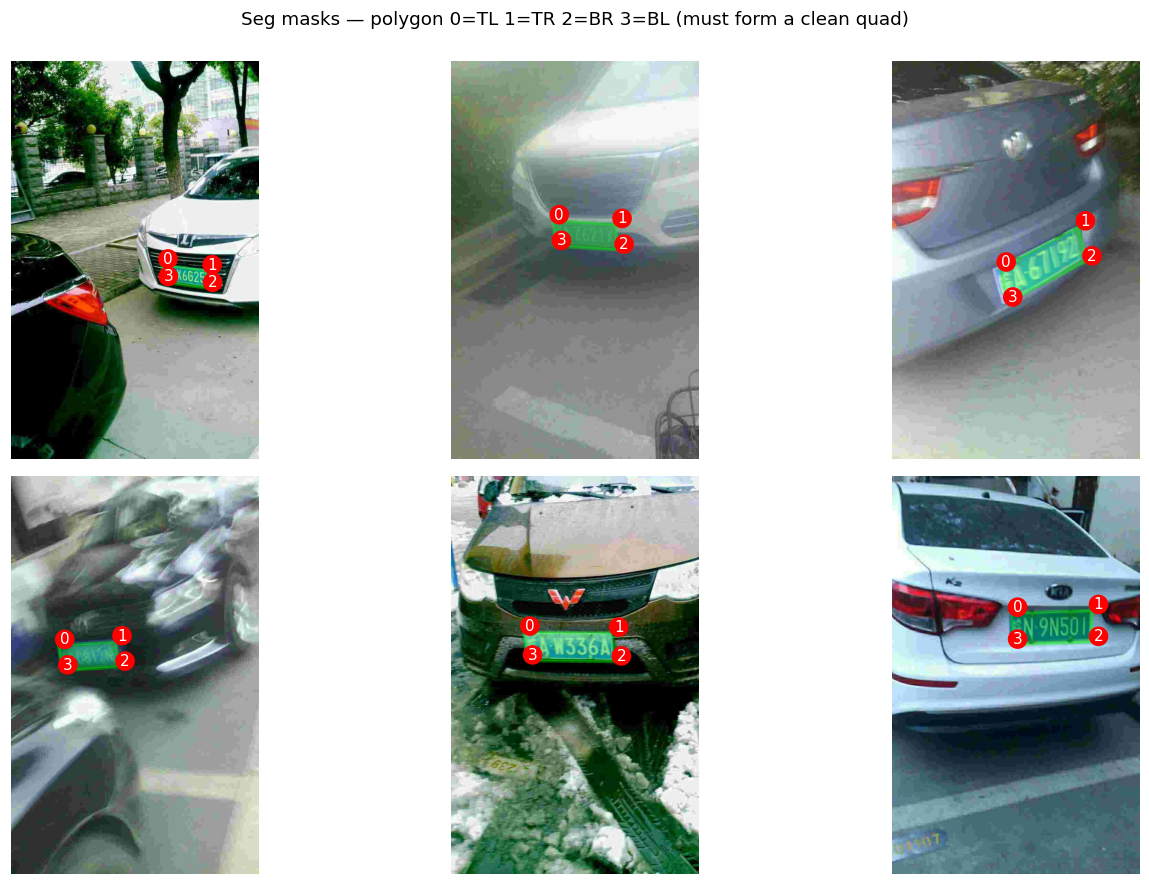

In [ ]:
from matplotlib.patches import Polygon as MplPolygon

def preview_seg_labels(work, sp="pool", n=6, seed=0):
    lbls = sorted((work/"labels"/sp).glob("*.txt"))
    if not lbls:
        print("no labels found"); return
    rng = random.Random(seed); rng.shuffle(lbls)
    lbls = lbls[:n]
    cols = 3; rows = math.ceil(len(lbls)/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*4.5, rows*4))
    axes = np.array(axes).reshape(-1)
    for ax, lp in zip(axes, lbls):
        img = Image.open(work/"images"/sp/(lp.stem + ".jpg")).convert("RGB")
        W, H = img.size
        ax.imshow(img)
        vals = list(map(float, lp.read_text().split()))
        poly = np.array(vals[1:]).reshape(-1, 2) * [W, H]
        ax.add_patch(MplPolygon(poly, closed=True, fill=True,
                                facecolor="lime", edgecolor="lime", alpha=0.35, lw=2))
        for i, (px, py) in enumerate(poly):
            ax.text(px+4, py-4, str(i), color="white", fontsize=10,
                    bbox=dict(boxstyle="circle,pad=0.15", fc="red", ec="none"))
        ax.axis("off")
    for ax in axes[len(lbls):]: ax.axis("off")
    plt.suptitle("Seg masks — polygon 0=TL 1=TR 2=BR 3=BL (must form a clean quad)", y=1.0)
    plt.tight_layout(); plt.show()

preview_seg_labels(SEG_WORK, "pool", n=6)


In [ ]:
def run_seg_cross_validation(size="n", pretrained=True, epochs=50, n_folds=N_FOLDS,
                             imgsz=IMGSZ, batch=BATCH, device=DEVICE, tag_prefix=""):
    """Train a seg `size`/`pretrained` config across all folds.
    Returns (per_fold_df, summary_dict). Mirrors run_cross_validation for pose."""
    weights = f"yolo11{size}-seg.pt" if pretrained else f"yolo11{size}-seg.yaml"
    cfg_tag = f"{tag_prefix}yolo11{size}_{'pretrained' if pretrained else 'scratch'}"
    rows = []
    for k in range(n_folds):
        run_name = f"{cfg_tag}_fold{k}"
        m = YOLO(weights)
        m.train(data=str(seg_fold_yamls[k]), epochs=epochs, imgsz=imgsz, batch=batch,
                device=device, patience=PATIENCE, fliplr=0.0, flipud=0.0,
                project="runs_plate_seg", name=run_name, exist_ok=True, verbose=False)
        mv = m.val(data=str(seg_fold_yamls[k]), split="val",
                   project="runs_plate_seg", name=run_name+"_val", exist_ok=True)
        try:
            row = {"fold": k,
                   "mask_mAP50-95": float(mv.seg.map),
                   "mask_mAP50":    float(mv.seg.map50),
                   "box_mAP50-95":  float(mv.box.map)}
        except Exception:
            row = {"fold": k, "mask_mAP50-95": np.nan,
                   "mask_mAP50": np.nan, "box_mAP50-95": np.nan}
        rows.append(row)
    df = pd.DataFrame(rows)
    summary = {
        "config": cfg_tag,
        "mask_mAP50-95_mean": float(df["mask_mAP50-95"].mean()),
        "mask_mAP50-95_std":  float(df["mask_mAP50-95"].std(ddof=0)),
        "mask_mAP50_mean":    float(df["mask_mAP50"].mean()),
        "box_mAP50-95_mean":  float(df["box_mAP50-95"].mean()),
    }
    return df, summary


In [ ]:
EPOCHS_CV_SEG = 40   
seg_cv_df, seg_cv_summary = run_seg_cross_validation(size="s", pretrained=True, epochs=EPOCHS_CV_SEG)
print("\nPer-fold results (seg):")
display(seg_cv_df)
print("\nCross-validated summary (seg):")
print(f"  mask mAP50-95 = {seg_cv_summary['mask_mAP50-95_mean']:.4f} ± {seg_cv_summary['mask_mAP50-95_std']:.4f}")
print(f"  mask mAP50    = {seg_cv_summary['mask_mAP50_mean']:.4f}")
print(f"   box  mAP50-95 = {seg_cv_summary['box_mAP50-95_mean']:.4f}")


New https://pypi.org/project/ultralytics/8.4.62 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.14.5 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060, 5739MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_seg_plate/folds/fold0/plate_seg.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0

,fold,mask_mAP50-95,mask_mAP50,box_mAP50-95
0,0,0.880145,0.994338,0.941076
1,1,0.875571,0.994294,0.942698
2,2,0.877366,0.994526,0.944457
3,3,0.877275,0.994463,0.939003



Cross-validated summary (seg):
  mask mAP50-95 = 0.8776 ± 0.0016
  mask mAP50    = 0.9944
  box  mAP50-95 = 0.9418


In [ ]:
RUN_SEG_GRID_CV = False   # set True to run the full cross-validated seg comparison (slow!)

EPOCHS_GRID_SEG = EPOCHS_GRID
seg_grid = [
    #("n", True),
    #("n", False),
     ("s", True),
    ("s", False),
    # ("m", True),
    # ("m", False),
]

if RUN_SEG_GRID_CV:
    seg_summaries, seg_per_fold_all = [], []
    for size, pre in seg_grid:
        print(f"\n=== SEG CV for yolo11{size} pretrained={pre} ===")
        dfk, summ = run_seg_cross_validation(size=size, pretrained=pre, epochs=EPOCHS_GRID_SEG)
        dfk["config"] = summ["config"]; seg_per_fold_all.append(dfk)
        seg_summaries.append(summ)
    seg_comp = pd.DataFrame(seg_summaries)
    seg_comp["mask_mAP50-95"] = seg_comp.apply(
        lambda r: f"{r['mask_mAP50-95_mean']:.4f} ± {r['mask_mAP50-95_std']:.4f}", axis=1)
    display(seg_comp[["config","mask_mAP50-95","mask_mAP50_mean","box_mAP50-95_mean"]])
    seg_comp.to_csv("plate_seg_cv_comparison.csv", index=False)
    pd.concat(seg_per_fold_all, ignore_index=True).to_csv("plate_seg_cv_perfold.csv", index=False)
    print("\nsaved plate_seg_cv_comparison.csv and plate_seg_cv_perfold.csv")
else:
    print("Set RUN_SEG_GRID_CV = True to run the cross-validated size × pretrained seg comparison.")


NameError: name 'EPOCHS_GRID' is not defined

In [ ]:
SEG_FINAL_SIZE       = "n"
SEG_FINAL_PRETRAINED = True
SEG_FINAL_EPOCHS     = 50

seg_final_weights = (f"yolo11{SEG_FINAL_SIZE}-seg.pt" if SEG_FINAL_PRETRAINED
                     else f"yolo11{SEG_FINAL_SIZE}-seg.yaml")
seg_final_model = YOLO(seg_final_weights)
seg_final_model.train(
    data=str(seg_final_yaml), epochs=SEG_FINAL_EPOCHS, imgsz=IMGSZ, batch=BATCH,
    device=DEVICE, patience=PATIENCE, fliplr=0.0, flipud=0.0,
    project="runs_plate_seg", name="final_model", exist_ok=True, verbose=True,
)

seg_test_metrics = seg_final_model.val(data=str(seg_final_yaml), split="test",
                                       project="runs_plate_seg", name="final_model_test", exist_ok=True)
try:
    print("\n=== FINAL SEG TEST-SET RESULTS ===")
    print("Mask mAP50-95:", round(float(seg_test_metrics.seg.map), 4))
    print("Mask mAP50   :", round(float(seg_test_metrics.seg.map50), 4))
    print("Box  mAP50-95:", round(float(seg_test_metrics.box.map), 4))
    print("Best weights :", seg_final_model.trainer.best)
except Exception as e:
    print("Metrics object:", seg_test_metrics, "|", e)


New https://pypi.org/project/ultralytics/8.4.57 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.14.5 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2060, 5730MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_seg_plate/plate_seg_final.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, mult

# Comparison between Seg and Pose

In [ ]:
import cv2

def corners_from_mask(mask, eps_frac_start=0.02, eps_frac_max=0.20):
    """Given a binary mask (HxW, uint8/bool), return 4 ordered corners (TL,TR,BR,BL)
    or None if a clean quad can't be fit. Falls back to minAreaRect if approx fails."""
    m = (np.asarray(mask) > 0).astype(np.uint8)
    if m.sum() == 0:
        return None
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)
    peri = cv2.arcLength(c, True)
    eps = eps_frac_start
    while eps <= eps_frac_max:
        approx = cv2.approxPolyDP(c, eps * peri, True)
        if len(approx) == 4:
            return order_corners(approx.reshape(-1, 2))
        eps += 0.01
    # fallback: minimum-area rotated rectangle
    box = cv2.boxPoints(cv2.minAreaRect(c))
    return order_corners(box)

print("corners_from_mask() ready — turns a seg mask into the same 4 corners the pose head predicts.")


corners_from_mask() ready — turns a seg mask into the same 4 corners the pose head predicts.


In [ ]:
cmp_imgs = sorted((WORK_ROOT/"images"/"test").glob("*.jpg"))[:4]
final_model = YOLO("runs/pose/runs_plate_pose/final_model/weights/best.pt")
seg_final_model = YOLO("runs/segment/runs_plate_seg/final_model/weights/best.pt")
pose_preds = final_model.predict(cmp_imgs, imgsz=IMGSZ, device=DEVICE, verbose=False)
seg_preds  = seg_final_model.predict(cmp_imgs, imgsz=IMGSZ, device=DEVICE, verbose=False)

rows = len(cmp_imgs)
fig, axes = plt.subplots(rows, 2, figsize=(10, rows*3.6))
axes = np.array(axes).reshape(rows, 2)

for r in range(rows):
    pr, sr = pose_preds[r], seg_preds[r]

    # left: pose corners
    axL = axes[r, 0]; axL.imshow(pr.orig_img[..., ::-1])
    if pr.keypoints is not None and len(pr.keypoints):
        kp = pr.keypoints.xy.cpu().numpy()[0]
        for i, (kx, ky) in enumerate(kp):
            axL.scatter([kx], [ky], c="red", s=40, zorder=5)
            axL.text(kx+4, ky-4, str(i), color="white", fontsize=9,
                     bbox=dict(boxstyle="circle,pad=0.1", fc="red", ec="none"))
    axL.set_title("POSE — predicted corners"); axL.axis("off")

    # right: seg mask + recovered corners
    axR = axes[r, 1]; axR.imshow(sr.orig_img[..., ::-1])
    if sr.masks is not None and len(sr.masks):
        mask = sr.masks.data[0].cpu().numpy()
        H, W = sr.orig_img.shape[:2]
        mask_full = cv2.resize(mask, (W, H), interpolation=cv2.INTER_NEAREST)
        axR.imshow(np.ma.masked_where(mask_full == 0, mask_full),
                   alpha=0.4, cmap="autumn")
        quad = corners_from_mask(mask_full)
        if quad is not None:
            for i, (px, py) in enumerate(quad):
                axR.scatter([px], [py], c="cyan", s=40, zorder=5)
                axR.text(px+4, py-4, str(i), color="black", fontsize=9,
                         bbox=dict(boxstyle="circle,pad=0.1", fc="cyan", ec="none"))
    axR.set_title("SEG — mask + recovered corners"); axR.axis("off")

plt.suptitle("Pose vs. Seg on the same test images", y=1.0)
plt.tight_layout(); plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'runs/pose/runs_plate_pose/final_model/weights/best.pt'

In [25]:
import torch, gc
import pandas as pd
import numpy as np
import cv2
from pathlib import Path
from ultralytics import YOLO


# definizione funzioni
import torch
import numpy as np
import cv2


def corners_from_mask(mask, eps_frac_start=0.02, eps_frac_max=0.20):
    """Given a binary mask (HxW, uint8/bool), return 4 ordered corners (TL,TR,BR,BL)
    or None if a clean quad can't be fit. Falls back to minAreaRect if approx fails."""
    m = (np.asarray(mask) > 0).astype(np.uint8)
    if m.sum() == 0:
        return None
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea)
    peri = cv2.arcLength(c, True)
    eps = eps_frac_start
    while eps <= eps_frac_max:
        approx = cv2.approxPolyDP(c, eps * peri, True)
        if len(approx) == 4:
            return order_corners(approx.reshape(-1, 2))
        eps += 0.01
    # fallback: minimum-area rotated rectangle
    box = cv2.boxPoints(cv2.minAreaRect(c))
    return order_corners(box)

def gt_corners_for(img_path):
    rec = parse_ccpd_filename(img_path)
    if rec is None: return None
    return order_corners(rec["vertices"]).astype(np.float32)

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

def _iter_batches(seq, n):
    for i in range(0, len(seq), n):
        yield seq[i:i+n]

def mean_corner_error_pose_2(model, img_paths, batch=8, imgsz=640):
    errs = []
    for chunk in _iter_batches(img_paths, batch):
        preds = model.predict(chunk, imgsz=imgsz, device=DEVICE, verbose=False)
        for p, r in zip(chunk, preds):
            gt = gt_corners_for(p)
            if gt is None or r.keypoints is None or len(r.keypoints) == 0:
                continue
            
            # Estrae i keypoint predetti da YOLO Pose
            pk = order_corners(r.keypoints.xy.cpu().numpy()[0]).astype(np.float32)
            
            # Calcola la distanza media in pixel rispetto ai veri angoli
            errs.append(np.linalg.norm(pk - gt, axis=1).mean())
            
        del preds
        if str(DEVICE) != "cpu":
            torch.cuda.empty_cache()
            
    return (float(np.mean(errs)) if errs else float("nan")), len(errs)


def mean_corner_error_seg_2(model, img_paths, batch=8, imgsz=640):
    errs = []
    for chunk in _iter_batches(img_paths, batch):
        preds = model.predict(chunk, imgsz=imgsz, device=DEVICE, verbose=False)
        for p, r in zip(chunk, preds):
            gt = gt_corners_for(p)
            if gt is None or r.masks is None or len(r.masks) == 0:
                continue
            
            # Prende le dimensioni dell'immagine originale su disco
            H, W = r.orig_img.shape[:2]
            
            # Ridimensiona la maschera di YOLO per farla combaciare con l'immagine originale
            mask = cv2.resize(r.masks.data[0].cpu().numpy(), (W, H), interpolation=cv2.INTER_NEAREST)
            
            # Estrae il poligono dalla maschera
            quad = corners_from_mask(mask)
            if quad is None: continue
            
            # Calcola la distanza media in pixel rispetto ai veri angoli
            errs.append(np.linalg.norm(quad.astype(np.float32) - gt, axis=1).mean())
            
        del preds
        if str(DEVICE) != "cpu":
            torch.cuda.empty_cache()
            
    return (float(np.mean(errs)) if errs else float("nan")), len(errs)

# 1. Prepara il dataset di test
test_imgs_all = sorted(Path("yolo_pose_plate/images/test").glob("*.jpg"))
EVAL_N = len(test_imgs_all) 
eval_imgs = test_imgs_all[:EVAL_N]
PRED_BATCH = 8

# 2. Configura i modelli da testare
# SOSTITUISCI i percorsi di "weights" con i path reali alle tue cartelle dei pesi.
# Se hai addestrato i modelli con una dimensione diversa da 640, aggiorna il valore "imgsz".
models_to_test = [
    {"name": "Pose Nano (n)",   "type": "pose", "imgsz": 640, "weights": "Dataset/runs/pose/runs_plate_pose/final_model_n/weights/best.pt"},
    {"name": "Pose Small (s)",  "type": "pose", "imgsz": 640, "weights": "Dataset/runs/pose/runs_plate_pose/final_model_s/weights/best.pt"},
    # {"name": "Pose Medium (m)", "type": "pose", "imgsz": 640, "weights": "percorso/a/pose_m/weights/best.pt"},
    
    {"name": "Seg Nano (n)",    "type": "seg",  "imgsz": 640, "weights": "Dataset/runs/segment/runs_plate_seg/final_model_n/weights/best.pt"},
    # {"name": "Seg Small (s)",   "type": "seg",  "imgsz": 640, "weights": "percorso/a/seg_s/weights/best.pt"},
    # {"name": "Seg Medium (m)",  "type": "seg",  "imgsz": 640, "weights": "percorso/a/seg_m/weights/best.pt"}
]


results = []

print(f"Inizio valutazione massiva su {EVAL_N} immagini di test...\n")

# 3. Loop di valutazione
for cfg in models_to_test:
    model_name = cfg["name"]
    weights_path = cfg["weights"]
    
    # Controllo di sicurezza per evitare errori a metà esecuzione
    if not Path(weights_path).exists():
        print(f"[WARNING] File non trovato per {model_name}: {weights_path} -> Salto il test.")
        continue
        
    print(f"Valutazione in corso: {model_name}...")
    
    # Pulisci la VRAM prima di caricare un nuovo modello
    gc.collect()
    if str(DEVICE) != "cpu":
        torch.cuda.empty_cache()
        
    # Carica i pesi del modello
    model = YOLO(weights_path)
    
    # Esegui l'inferenza in base al task
    if cfg["type"] == "pose":
        err, n_matched = mean_corner_error_pose_2(model, eval_imgs, imgsz=cfg["imgsz"], batch=PRED_BATCH)
    else:
        err, n_matched = mean_corner_error_seg_2(model, eval_imgs, imgsz=cfg["imgsz"], batch=PRED_BATCH)
        
    print(f" -> Errore medio: {err:.2f} pixel (Trovate: {n_matched}/{EVAL_N})\n")
    
    # Aggiungi al record dei risultati
    results.append({
        "Model_Name": model_name,
        "Task": cfg["type"].upper(),
        "Size": model_name.split()[-1].replace("(", "").replace(")", ""), # Estrae 'n', 's' o 'm'
        "Mean_Corner_Error_px": round(err, 3) if not np.isnan(err) else "N/A",
        "N_Matched": n_matched,
        "Success_Rate_%": round((n_matched / EVAL_N) * 100, 1)
    })

# 4. Crea il DataFrame e salva il CSV
if results:
    df_results = pd.DataFrame(results)

    # Ordina dal migliore al peggiore (errore più basso = migliore)
    df_results = df_results.sort_values(by="Mean_Corner_Error_px", ascending=True).reset_index(drop=True)

    print("=== CLASSIFICA FINALE DEI MODELLI ===")
    print(df_results.to_string())

    # Salva su disco
    csv_filename = "benchmark_pose_vs_seg.csv"
    df_results.to_csv(csv_filename, index=False)
    print(f"\nSalvato con successo: {csv_filename}")
else:
    print("Nessun modello valutato. Controlla i percorsi dei file best.pt.")




Inizio valutazione massiva su 1173 immagini di test...

Valutazione in corso: Pose Nano (n)...
 -> Errore medio: 4.76 pixel (Trovate: 1173/1173)

Valutazione in corso: Pose Small (s)...
 -> Errore medio: 4.65 pixel (Trovate: 1173/1173)

Valutazione in corso: Seg Nano (n)...
 -> Errore medio: 7.87 pixel (Trovate: 1172/1173)

=== CLASSIFICA FINALE DEI MODELLI ===
       Model_Name  Task Size  Mean_Corner_Error_px  N_Matched  Success_Rate_%
0  Pose Small (s)  POSE    s                 4.649       1173           100.0
1   Pose Nano (n)  POSE    n                 4.761       1173           100.0
2    Seg Nano (n)   SEG    n                 7.874       1172            99.9

Salvato con successo: benchmark_pose_vs_seg.csv
